3. Model Selection 

In this notebook we will look at different models and compare there performance.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from data.dataset import Dataset
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt

from models.random_guessing_benchmark import RandomGuessingBenchmark
from evaluation.evaluation_metrics import EvaluationMetrics
from models.cnn_builder import CNNBuilder  


/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3.1 Get and prepare Data

Here I load the data from disk and we first normalize the image arrays, in order to have smaller input values for the neural network, for better training. I also split the data into training set and test set. The data will be split in 80% training data and 20% test data. 

In [2]:
dataset = Dataset()
X, y = dataset.get_prep_data()

# Normalize the image data
X = X.astype("float32") / 255.0

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1))

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 2000 samples
Test set: 500 samples
Input shape: (168, 120, 3)
Number of classes: 5


3.2 Benchmark: Random Guessing

With our 5 balanced classes, random guessing should give ~20% accuracy. This benchmark should act as our lower bound and our model should be able to be better than that.


In [3]:
random_benchmark = RandomGuessingBenchmark()
y_pred_random = random_benchmark.predict(X_test)
eval_metrics = EvaluationMetrics(y_test, y_pred_random)
eval_metrics.print_eval_metrics()

Accuracy: 0.206


3.3 Simple ANN




In [4]:
def build_simple_ann():
    model = Sequential([
        Input(shape=(168, 120, 3)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

simple_ann = build_simple_ann()
simple_ann.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)
y_pred_ann = simple_ann.predict(X_test)
y_pred_classes = np.argmax(y_pred_ann, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
eval_metrics_ann = EvaluationMetrics(y_true_classes, y_pred_classes)
eval_metrics_ann.print_eval_metrics()

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.2944 - loss: 8.5561 - val_accuracy: 0.4450 - val_loss: 3.3931
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4567 - loss: 2.4839 - val_accuracy: 0.4700 - val_loss: 1.5955
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4633 - loss: 1.8238 - val_accuracy: 0.5550 - val_loss: 1.2046
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5800 - loss: 1.1259 - val_accuracy: 0.4350 - val_loss: 1.7599
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5489 - loss: 1.3833 - val_accuracy: 0.4350 - val_loss: 1.9372
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5656 - loss: 1.6039 - val_accuracy: 0.5250 - val_loss: 1.8622
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5517 - loss: 1.5580 - val_accuracy: 0.5050 - val_loss: 1.3433
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6533 - loss: 0.9326 - val_accuracy: 0.6250 - v

3.4 CNN


In [5]:
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
cnn_model = builder.build_model()
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)
y_pred_cnn = cnn_model.predict(X_test)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
eval_metrics_cnn = EvaluationMetrics(y_true_classes, y_pred_classes_cnn)
eval_metrics_cnn.print_eval_metrics()

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.4078 - loss: 1.5004 - val_accuracy: 0.5050 - val_loss: 1.0568
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step - accuracy: 0.6067 - loss: 0.9611 - val_accuracy: 0.6350 - val_loss: 0.9191
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 354ms/step - accuracy: 0.7539 - loss: 0.6543 - val_accuracy: 0.6400 - val_loss: 0.9009
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 264ms/step - accuracy: 0.8333 - loss: 0.4655 - val_accuracy: 0.6650 - val_loss: 0.9417
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 269ms/step - accuracy: 0.8856 - loss: 0.3303 - val_accuracy: 0.7100 - val_loss: 0.8559
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - accuracy: 0.9406 - loss: 0.1874 - val_accuracy: 0.7050 - val_loss: 0.8995
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 299ms/step - accuracy: 0.9606 - loss: 0.1322 - val_accuracy: 0.7650 - val_loss: 0.8213
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 270ms/step - accuracy: 0.9750 - loss: 0.0834 - val_accu

3.4 Comparison

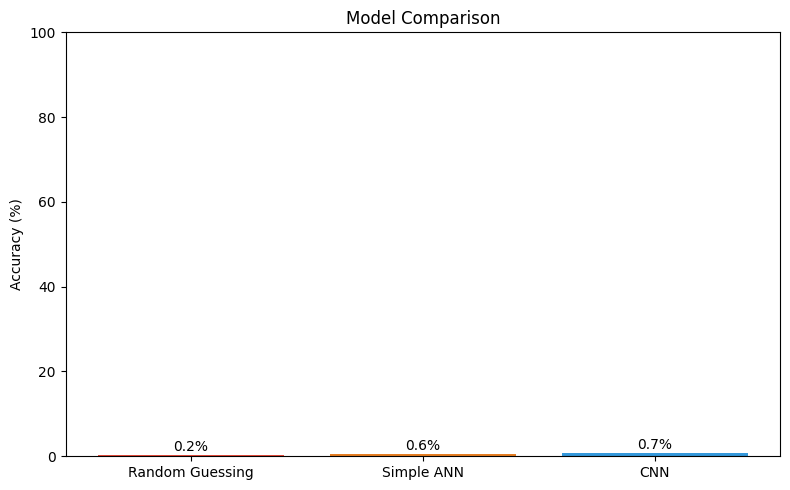

In [ ]:
results = {
    "Random Guessing": eval_metrics.accuracy * 100,
    "Simple ANN": eval_metrics_ann.accuracy * 100,
    "CNN": eval_metrics_cnn.accuracy * 100
}

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.ylim(0, 100)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 1, f'{acc:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()